## Detecting Gravitational waves
In this exercise, our goal is to classify whether a gravitational wave (GW) source is detectable or not, based on its observed features.
To accomplish this, we employ different discrimative classification strategies such as Decision Tree Classifier and Random Forest

In [2]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import mean_squared_error
import numpy as np
from matplotlib import pyplot as plt
import sklearn.model_selection 
from sklearn.mixture import GaussianMixture
from astroML.resample import jackknife
import scipy
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from scipy.stats import loguniform
from sklearn import datasets
from sklearn import manifold
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
path = './sample_2e7_design_precessing_higherordermodes_3detectors.h5'
from astropy.table import Table
from astroML.utils import completeness_contamination
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import zero_one_loss
from sklearn.metrics import log_loss

In [3]:
def get_errors(xtrain, ytrain, xval, yval, model):

    pred_train = model.predict(xtrain)
    pred_val = model.predict(xval)

    err_train = np.sqrt(np.sum((ytrain - pred_train)**2)/len(xtrain))
    err_val = np.sqrt(np.sum((yval - pred_val)**2)/len(xval))

    return err_train, err_val

In [4]:
#!pip install h5py

In [5]:
import h5py
file = 'sample_2e7_design_precessing_higherordermodes_3detectors.h5'
name = ['mtot','q','chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'psi','z', 'det']
data = h5py.File(file, 'r')
"""
with h5py.File(file, 'r') as data:
    data_keys = list(data.keys())[0]
    
    #dataset = list(data[data_keys])
    print(data.keys())
print(dataset)
"""
print(data['det'][:10])
gw_tot = []
for i in range(len(name)):
    gw_tot.append(data[name[i]][:10**5])
gw_array = np.array(gw_tot).T

print(gw_array.shape)


[0 0 0 0 1 0 0 1 0 1]
(100000, 13)


## Decision tree classifier

A Decision Tree classifier is a supervised learning algorithm that recursively splits the dataset into subsets based on feature thresholds. At each step, the algorithm chooses the split that maximizes the information gain, effectively reducing the uncertainty (entropy) about the class labels in the resulting subsets.

In [6]:
#Cross validation for optimal maximum depth
tree_depth = {'max_depth': np.arange(1, 21)}
tree = DecisionTreeClassifier(random_state = 0, criterion = 'entropy')
x = gw_array[:,:-1]
y = gw_array[:,-1]
print(x.shape)
print(y.shape)
cv = KFold(n_splits=5, shuffle=True, random_state=0)
grid = GridSearchCV(tree, tree_depth, cv=cv, return_train_score = True)
grid.fit(x, y)

print(f"Best depth: {grid.best_params_['max_depth']}")
print(f"Best score: {grid.best_score_}")

(100000, 12)
(100000,)
Best depth: 10
Best score: 0.95746


In [7]:
best_depth = grid.best_params_['max_depth']

In [8]:
tree = DecisionTreeClassifier(random_state = 0, criterion = 'entropy', max_depth = best_depth)
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42)
tree.fit(xtrain, ytrain)
ypred = tree.predict(xtest)

In [9]:
#Confusion matrix
C = confusion_matrix(ytest, ypred)
print(C)
accuracy = accuracy_score(ytest, ypred)
print(accuracy)
tn, fp, fn, tp = C.ravel()
print(fn)
print(fp)

[[25032   646]
 [  669  3653]]
0.9561666666666667
669
646


Our Decision Tree presents 646 false positives and 669 false negatives with an accuracy of 95.6%

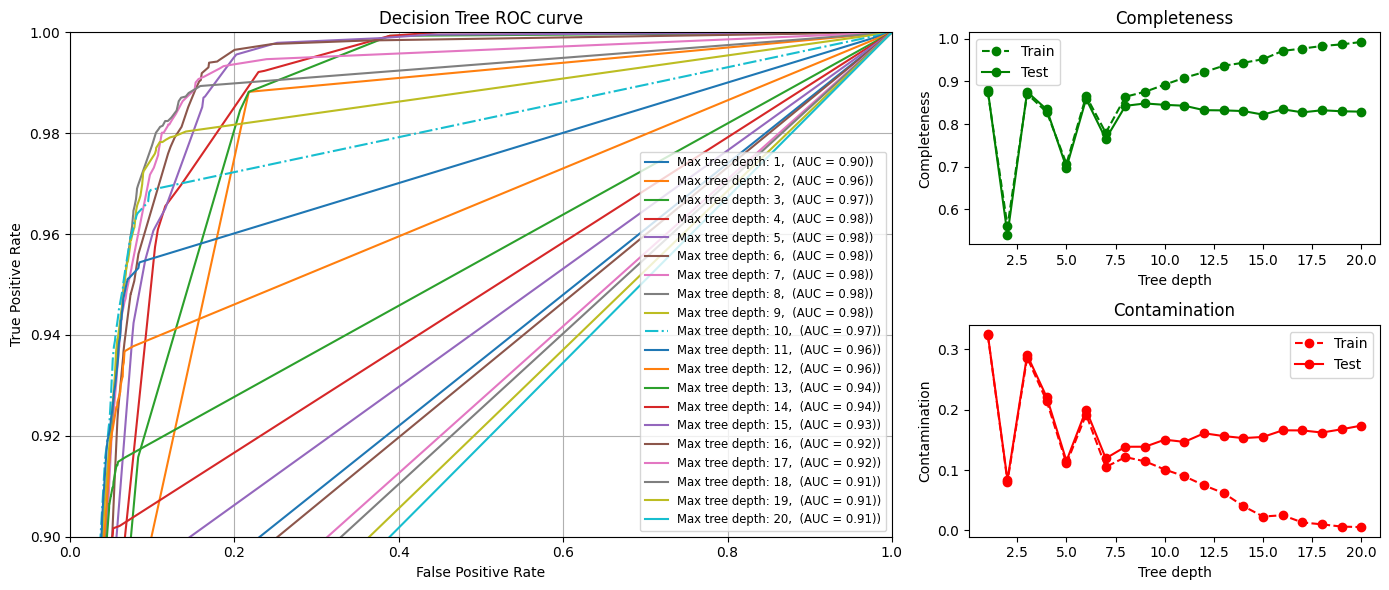

<Figure size 640x480 with 0 Axes>

In [10]:
completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []
err_train = []
err_validation = []
roc_curves = []
tree_depth = np.arange(1,21)
for k in tree_depth:
    #fitting the data with an increasing number of branches
    tree = DecisionTreeClassifier(random_state = 0, criterion = 'entropy', max_depth = k)
    tree.fit(xtrain, ytrain)
    

    
    y_prob = tree.predict_proba(xtest)[:,1]
    
    #compute the false positive rate, true positive rate and the threshold
    fpr, tpr, thresh = roc_curve(ytest, y_prob)  
    y_pred = tree.predict(xtest)
    roc_auc = auc(fpr, tpr)

    y_prob_train = tree.predict_proba(xtrain)[:, 1]
    
    loss_val = log_loss(ytest, y_prob) #logistic loss function
    loss_train = log_loss(ytrain, y_prob_train)

                        
    
    comp, cont = completeness_contamination(y_pred, ytest)
    y_pred = tree.predict(xtrain)
    comp_t, cont_t = completeness_contamination(y_pred, ytrain)
    completeness_test.append(comp)
    contamination_test.append(cont)

    completeness_train.append(comp_t)
    contamination_train.append(cont_t)
    

   
    
    err_train.append(loss_train)
    err_validation.append(loss_val)
    
    roc_curves.append((fpr, tpr,roc_auc, k)) 

    


# Plot
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, k in roc_curves:
    if k == 10:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))', linestyle = '-.')
    else:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))')
ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('Decision Tree ROC curve')
ax0.grid(True)
ax0.legend(fontsize = 'small')


ax2 = plt.subplot(2, 2, 2)  # Completeness
ax2.plot(tree_depth, completeness_train, 'g--o', label='Train')
ax2.plot(tree_depth, completeness_test, 'g-o', label='Test')
ax2.set_title("Completeness")
ax2.set_xlabel("Tree depth")
ax2.set_ylabel("Completeness")
ax2.legend()

ax3 = plt.subplot(2, 2, 4)  # Contamination
ax3.plot(tree_depth, contamination_train, 'r--o', label='Train')
ax3.plot(tree_depth, contamination_test, 'r-o', label='Test')
ax3.set_title("Contamination")
ax3.set_xlabel("Tree depth")
ax3.set_ylabel("Contamination")
ax3.legend()

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


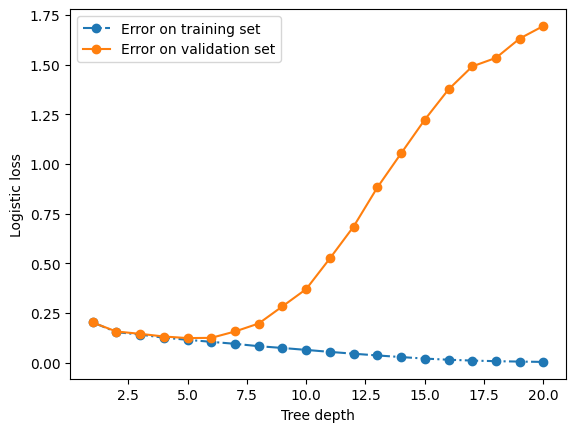

In [11]:
plt.plot(tree_depth, err_train, marker ='o', linestyle = '-.', label = 'Error on training set')
plt.plot(tree_depth, err_validation, marker ='o', label = 'Error on validation set')
plt.xlabel("Tree depth")
plt.ylabel("Logistic loss")
plt.legend()

Although the cross-validation selected max_depth = 10 as optimal, its ROC curve is not the best. The discrepancy arises because GridSearchCV optimized for accuracy, which only evaluates model performance at a fixed threshold, while the ROC curve considers the trade-off between TPR and FPR across all thresholds. As a result, the model with the best accuracy might not yield the best ROC performance.
Moreover, from the logistic loss of the training and validation set and completeness and contamination plot, we can see that the algorithm starts to overfit when the maximum depth exceeds 8.


In [12]:
cv_roc = KFold(n_splits=5, shuffle=True, random_state=0)
tree_max = {'max_depth': np.arange(1, 15)}
tree_roc = DecisionTreeClassifier(random_state = 0, criterion = 'entropy')
grid_roc = GridSearchCV(tree_roc, tree_max, cv=cv_roc, scoring = 'roc_auc', return_train_score = True)
grid_roc.fit(x, y)

print(f"Best depth: {grid_roc.best_params_['max_depth']}")
print(f"Best score: {grid_roc.best_score_}")


Best depth: 8
Best score: 0.9828613982541569


In [13]:
tree = DecisionTreeClassifier(random_state = 0, criterion = 'entropy', max_depth = 8)
tree.fit(xtrain, ytrain)
ypred = tree.predict(xtest)
accuracy_tree = accuracy_score(ytest, ypred)
print(accuracy_tree)


0.9578333333333333


Decision tree classifies our detections with an accuracy of:
- $Accuracy = 96\%$
- $Accuracy_{roc} = 98.3\% $

And with an optimal depth of 8:
- $Accuracy = 96\%$        

## Random forest

Random Forest is an ensemble learning algorithm that builds multiple Decision Trees by applying bootstrapping; that is, it creates several different training subsets by sampling with replacement from the original dataset.
Unlike a standard Decision Tree, each tree in the Random Forest only considers a random subset of features when splitting nodes. This strategy reduces the correlation between individual trees and helps to decrease overfitting, leading to a more robust and lower-bias model.

In [14]:
#K fold Cross validation for optimal tree depth
cv_rnd = KFold(n_splits=5, shuffle=True, random_state=0)
tree_max = {'max_depth': np.arange(1, 26)}
tree_rnd = RandomForestClassifier(random_state = 0, criterion = 'entropy')
grid_rnd = GridSearchCV(tree_rnd, tree_max, cv=cv_rnd, n_jobs=-1, return_train_score = True)
grid_rnd.fit(x, y)

print(f"Best depth: {grid_rnd.best_params_['max_depth']}")
print(f"Best score: {grid_rnd.best_score_}")


Best depth: 21
Best score: 0.96607


In [15]:
cv_results = grid_rnd.cv_results_
train_scores = cv_results['mean_train_score']
test_scores = cv_results['mean_test_score']
print("Train scores:", train_scores)
print("Test scores:", test_scores)


Train scores: [0.85618   0.85618   0.8798175 0.9425175 0.955905  0.9587375 0.96091
 0.96285   0.9653375 0.968995  0.972985  0.977935  0.9826775 0.986775
 0.9908325 0.993925  0.99638   0.998035  0.9991375 0.99969   0.999885
 0.99997   0.9999875 1.        1.       ]
Test scores: [0.85618 0.85618 0.87949 0.94115 0.95401 0.95659 0.95797 0.95867 0.95961
 0.96146 0.96193 0.96296 0.96398 0.96428 0.9651  0.96537 0.96553 0.9653
 0.96559 0.96576 0.96607 0.96551 0.9655  0.96592 0.96574]


In [16]:
tree_max = grid_rnd.best_params_['max_depth']
rf = RandomForestClassifier(random_state = 0, criterion = 'entropy', max_depth = tree_max)
rf.fit(xtrain, ytrain)
ypred = rf.predict(xtest)
C = confusion_matrix(ytest, ypred)
print(C)
tn, fp, fn, tp = C.ravel()

completeness_sklearn = recall_score(ytest, ypred)
contamination_sklearn = 1 - precision_score(ytest, ypred)
accuracy = accuracy_score(ytest, ypred)
print("Completeness", completeness_sklearn)
print("Contamination", contamination_sklearn)
print("Accuracy", accuracy)

[[25292   386]
 [  626  3696]]
Completeness 0.8551596483109671
Contamination 0.09456148946594811
Accuracy 0.9662666666666667


C:\Users\alexv\AppData\Local\Temp\ipykernel_13208\2906692729.py:26: RuntimeWarning: invalid value encountered in scalar divide
  cont = (fp/(tp+fp))
C:\Users\alexv\AppData\Local\Temp\ipykernel_13208\2906692729.py:32: RuntimeWarning: invalid value encountered in scalar divide
  cont_t = (fp/(tp+fp))
C:\Users\alexv\AppData\Local\Temp\ipykernel_13208\2906692729.py:26: RuntimeWarning: invalid value encountered in scalar divide
  cont = (fp/(tp+fp))
C:\Users\alexv\AppData\Local\Temp\ipykernel_13208\2906692729.py:32: RuntimeWarning: invalid value encountered in scalar divide
  cont_t = (fp/(tp+fp))


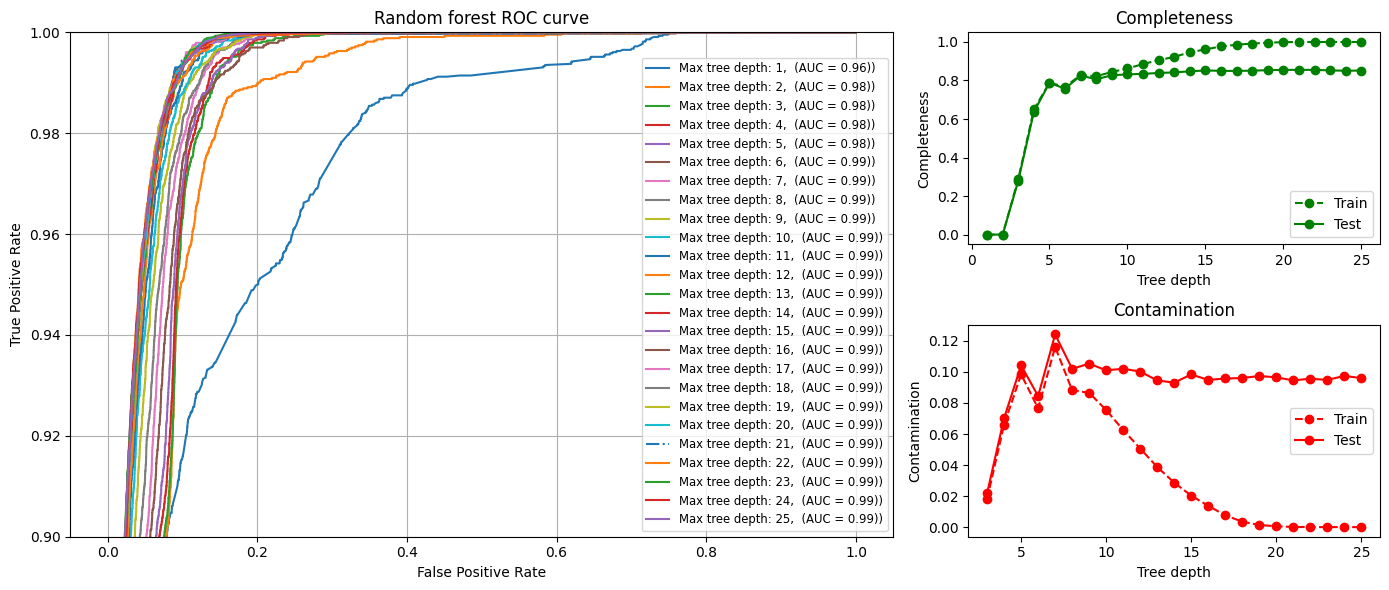

<Figure size 640x480 with 0 Axes>

In [17]:
completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []
roc_curves = []
tree_depth = np.arange(1, 26)
err_train = []
err_validation = []

for k in tree_depth:
    # Fitting the Random Forest with current depth
    rf = RandomForestClassifier(random_state=0, criterion='entropy', max_depth=k)
    rf.fit(xtrain, ytrain)
    
    # Predict probabilities and compute ROC
    y_prob = rf.predict_proba(xtest)[:, 1]
    fpr, tpr, thresh = roc_curve(ytest, y_prob)
    roc_auc = auc(fpr, tpr)

    

    y_pred_test = rf.predict(xtest)
    C = sklearn.metrics.confusion_matrix(ytest, y_pred_test)
    tn, fp, fn, tp = C.ravel()
    comp = (tp/(tp+fn))
    cont = (fp/(tp+fp))

    y_pred_train = rf.predict(xtrain)
    C = sklearn.metrics.confusion_matrix(ytrain, y_pred_train)
    tn, fp, fn, tp = C.ravel()
    comp_t = (tp/(tp+fn))
    cont_t = (fp/(tp+fp))
    
  
    completeness_test.append(comp)
    contamination_test.append(cont)
    completeness_train.append(comp_t)
    contamination_train.append(cont_t)
    
    y_prob_train = rf.predict_proba(xtrain)[:, 1]
    
    loss_val = log_loss(ytest, y_prob) #logistic loss function
    loss_train = log_loss(ytrain, y_prob_train)

                        
    err_train.append(loss_train)
    err_validation.append(loss_val)
    
    roc_curves.append((fpr, tpr, roc_auc, k))


# Plot
fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, k in roc_curves:
    if k == tree_max:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))', linestyle = '-.')
    else:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))')
#ax0.set_xlim([0, 1])
ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('Random forest ROC curve')
ax0.grid(True)
ax0.legend(fontsize = 'small')

ax2 = plt.subplot(2, 2, 2)  # Completeness
ax2.plot(tree_depth, completeness_train, 'g--o', label='Train')
ax2.plot(tree_depth, completeness_test, 'g-o', label='Test')
ax2.set_title("Completeness")
ax2.set_xlabel("Tree depth")
ax2.set_ylabel("Completeness")
ax2.legend()

ax3 = plt.subplot(2, 2, 4)  # Contamination
ax3.plot(tree_depth, contamination_train, 'r--o', label='Train')
ax3.plot(tree_depth, contamination_test, 'r-o', label='Test')
ax3.set_title("Contamination")
ax3.set_xlabel("Tree depth")
ax3.set_ylabel("Contamination")
ax3.legend()

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()


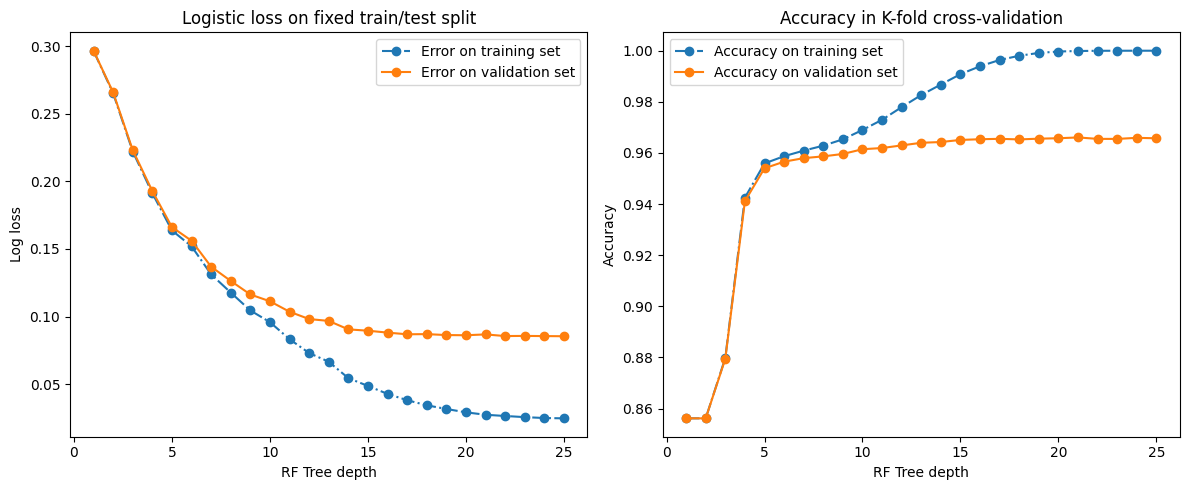

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Logistic loss
axs[0].plot(tree_depth, err_train, marker='o', linestyle='-.', label='Error on training set')
axs[0].plot(tree_depth, err_validation, marker='o', label='Error on validation set')
axs[0].set_xlabel("RF Tree depth")
axs[0].set_ylabel("Log loss")
axs[0].set_title("Logistic loss on fixed train/test split")
axs[0].legend()

# Accuracy in cross-validation
axs[1].plot(tree_depth, train_scores, marker='o', linestyle='-.', label='Accuracy on training set')
axs[1].plot(tree_depth, test_scores, marker='o', label='Accuracy on validation set')
axs[1].set_xlabel("RF Tree depth")
axs[1].set_ylabel("Accuracy")
axs[1].set_title("Accuracy in K-fold cross-validation")
axs[1].legend()

plt.tight_layout()
plt.show()


The Random Forest classifier seems to perform better than the simple Decision tree already with small tree depth. However from RMS and the Completeness and contamination plots the classifier seems to overfit above 10. In particular the log loss on the training set decreases as the tree depth deepens, whereas on the validation set the log loss flattens above 15. A similar trend is observed in the Accuracy plot, presenting a weak growth on the validation set above depth 10.

In [19]:
cv_rnd = KFold(n_splits=5, shuffle=True, random_state=0)
tree_max = {'max_depth': np.arange(1, 26)}
tree_rnd = RandomForestClassifier(random_state = 0, criterion = 'entropy')
grid_rnd = GridSearchCV(tree_rnd, tree_max, cv=cv_rnd, n_jobs=-1, scoring = 'roc_auc', return_train_score = True)
grid_rnd.fit(x, y)

print(f"Best depth: {grid_rnd.best_params_['max_depth']}")
print(f"Best score: {grid_rnd.best_score_}")


Best depth: 21
Best score: 0.992224687387599


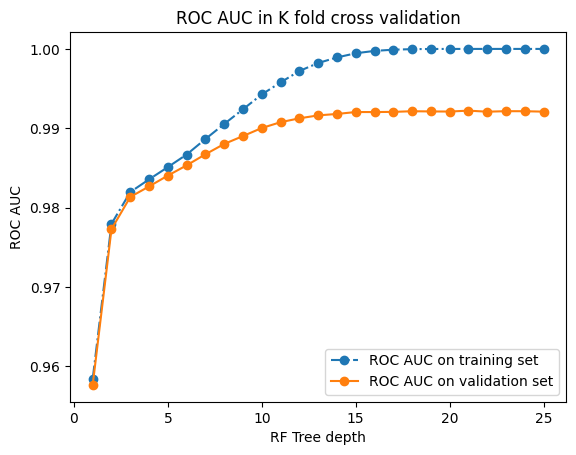

In [20]:
cv_results = grid_rnd.cv_results_
train_scores = cv_results['mean_train_score']
test_scores = cv_results['mean_test_score']
plt.plot(tree_depth, train_scores, marker ='o', linestyle = '-.', label = 'ROC AUC on training set')
plt.plot(tree_depth, test_scores, marker ='o', label = 'ROC AUC on validation set')
plt.xlabel("RF Tree depth")
plt.ylabel("ROC AUC")
plt.title("ROC AUC in K fold cross validation")
plt.legend()

The ROC AUC on the validation set increases up to approximately a depth of 15, then flattens out without further significant improvements.
These observations suggest that a depth greater than 15 does not bring benefits in terms of generalisation, but leads to increased complexity and the risk of overfitting. Therefore, the optimal depth can be set at around 15 or slightly lower

The Random forest performs better than the Decision tree in both cases with an accuracy:
- $Accuracy = 96.6\%$
- $Accuracy_{roc} = 99.2\%$
        



In [21]:
#Accuracy for depth 15
tree = RandomForestClassifier(random_state = 0, criterion = 'entropy', max_depth = 15)
tree.fit(xtrain, ytrain)
ypred = tree.predict(xtest)
accuracy_rf = accuracy_score(ytest, ypred)
print(accuracy_rf)


0.9653


With an optimal depth of 15, the Random forest classifies correctly detectable sources with an accuracy of:
- $Accuracy = 96.2\%$

## Using SNR to classify detectable sources
Instead of running a classifier predicting the value of data['det'], we can use a Random Forest Regressor predicting the expected SNR of a given source with certain characteristics. In particular, sources with an SNR above 8 can be detected by our detectors.

In [22]:
y_new = data['snr'][:10**5]
y_new = np.log10(y_new) #the snr varies over several orders of magnitude
x_train, x_test, y_train, y_test = train_test_split(x, y_new, test_size=0.3, random_state=42)


completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []
roc_curves = []


In [23]:

cv_snr = KFold(n_splits=5, shuffle=True, random_state=0)
tree_max = {'max_depth': np.arange(1, 26)}
tree_snr = RandomForestRegressor(random_state = 0 )
grid_snr = GridSearchCV(tree_snr, tree_max, cv=cv_snr, n_jobs=-1, scoring='neg_mean_absolute_error', return_train_score = True)
grid_snr.fit(x, y_new)

print(f"Best depth: {grid_snr.best_params_['max_depth']}")
print(f"Best score: {grid_snr.best_score_}")
best_depth = grid_snr.best_params_['max_depth']


Best depth: 19
Best score: -0.12653301792236954


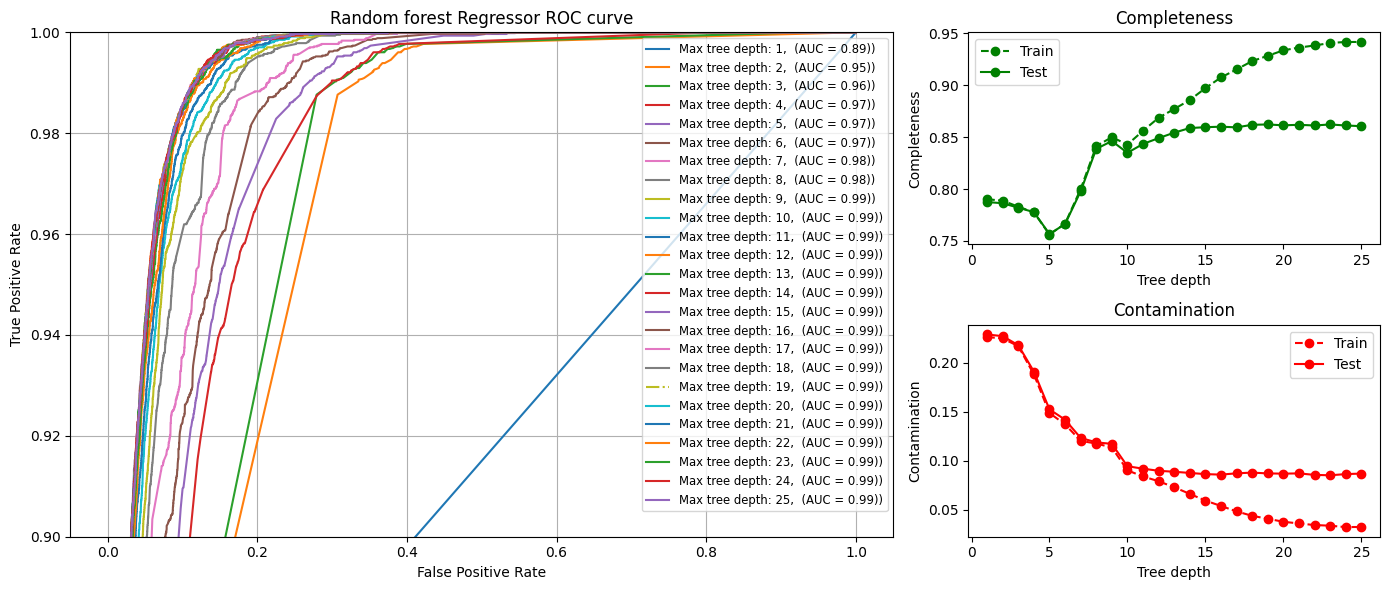

In [24]:

mae_test = []
mae_train = []

completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

accuracy_test = []
accuracy_train = []

roc_curves = []

threshold = np.log10(8)  # SNR over which i detect a GW
tree_depth = np.arange(1, 26)

for k in tree_depth:
    
    rf = RandomForestRegressor(random_state=0, max_depth=k)
    rf.fit(x_train, y_train)
    #predict 
    y_pred_test = rf.predict(x_test)
    y_pred_train = rf.predict(x_train)

  
    
    #MAE more robust to outliers
    mae_tr = mean_absolute_error(y_train, y_pred_train)
    
    mae_val = mean_absolute_error(y_test, y_pred_test)
    
    
    mae_train.append(mae_tr)
    mae_test.append(mae_val)
  

    # The snr above the threshold is converted in class = 1
    y_class_test = (y_pred_test > threshold).astype(int)
    y_class_train = (y_pred_train > threshold).astype(int)

    y_true_test = (y_test > threshold).astype(int)
    y_true_train = (y_train > threshold).astype(int)

    #Completeness and contamination
    comp_test = recall_score( y_true_test, y_class_test)
    cont_test = 1 - precision_score( y_true_test, y_class_test)
    
    completeness_test.append(comp_test)
    contamination_test.append(cont_test)


    comp_train = recall_score( y_true_train, y_class_train)
    cont_train = 1 - precision_score( y_true_train, y_class_train)
    
 
    completeness_train.append(comp_train)
    contamination_train.append(cont_train)

    # Accuracy
    accuracy_test.append(accuracy_score(y_true_test, y_class_test))
    accuracy_train.append(accuracy_score(y_true_train, y_class_train))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true_test, y_pred_test)
    roc_auc = auc(fpr, tpr)
    roc_curves.append((fpr, tpr, roc_auc, k))

fig = plt.figure(figsize=(14, 6))
gs = GridSpec(2, 2, width_ratios=[2, 1])

# ROC plot
ax0 = fig.add_subplot(gs[:, 0])
for fpr, tpr, auc_val, k in roc_curves:
    if k == best_depth:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))', linestyle = '-.')
    else:
        ax0.plot(fpr, tpr, label=f'Max tree depth: {k},  (AUC = {auc_val:.2f}))')

ax0.set_ylim([0.9, 1])
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('Random forest Regressor ROC curve')
ax0.grid(True)
ax0.legend(fontsize = 'small')

ax2 = plt.subplot(2, 2, 2)  # Completeness
ax2.plot(tree_depth, completeness_train, 'g--o', label='Train')
ax2.plot(tree_depth, completeness_test, 'g-o', label='Test')
ax2.set_title("Completeness")
ax2.set_xlabel("Tree depth")
ax2.set_ylabel("Completeness")
ax2.legend()

ax3 = plt.subplot(2, 2, 4)  # Contamination
ax3.plot(tree_depth, contamination_train, 'r--o', label='Train')
ax3.plot(tree_depth, contamination_test, 'r-o', label='Test')
ax3.set_title("Contamination")
ax3.set_xlabel("Tree depth")
ax3.set_ylabel("Contamination")
ax3.legend()

plt.tight_layout()
plt.show()



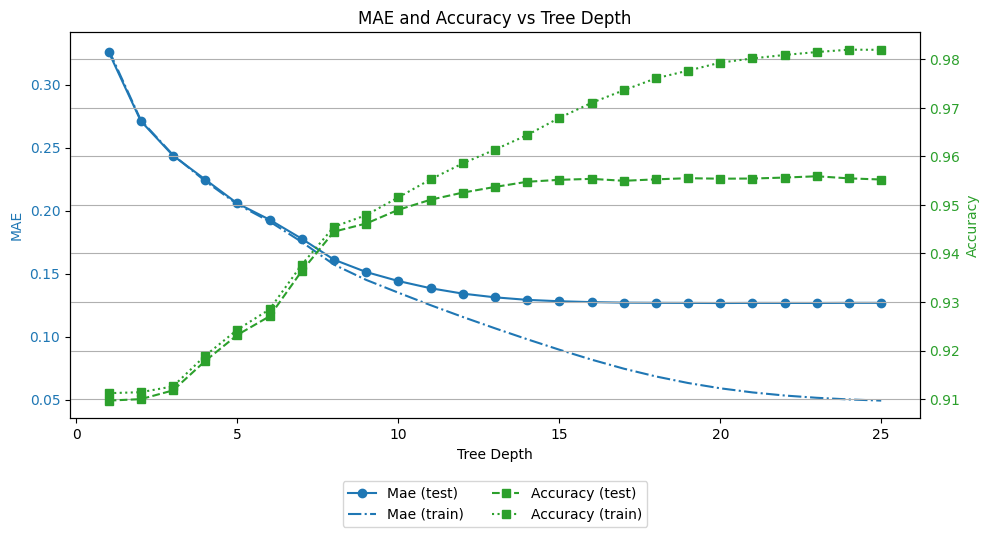

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_rmse = 'tab:blue'
color_acc = 'tab:green'

# MAE
ax1.set_xlabel('Tree Depth')
ax1.set_ylabel('MAE', color=color_rmse)
line1, = ax1.plot(tree_depth, mae_test, 'o-', label='Mae (test)', color=color_rmse)
line2, = ax1.plot(tree_depth, mae_train, '-.', label='Mae (train)', color=color_rmse)
ax1.tick_params(axis='y', labelcolor=color_rmse)

# Accuracy
ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color=color_acc)
line3, = ax2.plot(tree_depth, accuracy_test, 's--', label='Accuracy (test)', color=color_acc)
line4, = ax2.plot(tree_depth, accuracy_train, 's:', label='Accuracy (train)', color=color_acc)
ax2.tick_params(axis='y', labelcolor=color_acc)


lines = [line1, line2, line3, line4]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)


plt.title('MAE and Accuracy vs Tree Depth')
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.grid(True)
plt.show()


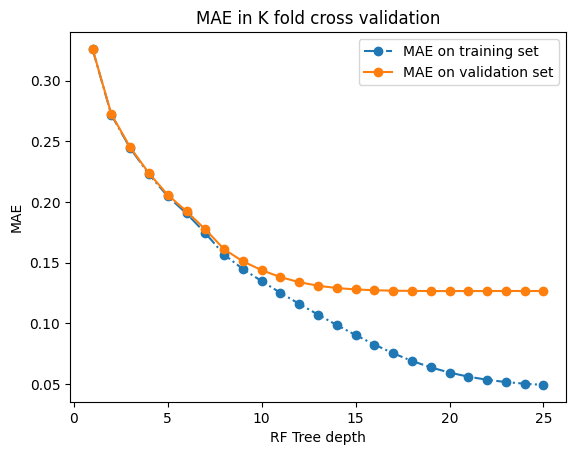

In [26]:
cv_results = grid_snr.cv_results_
train_scores = -cv_results['mean_train_score']
test_scores = -cv_results['mean_test_score']
plt.plot(tree_depth, train_scores, marker ='o', linestyle = '-.', label = 'MAE on training set')
plt.plot(tree_depth, test_scores, marker ='o', label = 'MAE on validation set')
plt.xlabel("RF Tree depth")
plt.ylabel("MAE")
plt.title("MAE in K fold cross validation")
plt.legend()


Our regressor accurately predicts whether a source is detectable, with performance improving as tree depth increases. However, beyond a depth of 15, signs of overfitting emerge, as indicated by the growing gap, between the training and validation sets, in completeness, mae and accuracy 


In [27]:
ma_err = (-grid_snr.best_score_)
print("Mean absolute error:", ma_err)
rf = RandomForestRegressor(random_state=0, max_depth= 15)
rf.fit(x_train, y_train)

y_pred_test = rf.predict(x_test)

y_class_test = (y_pred_test > threshold).astype(int)
y_true_test = (y_test > threshold).astype(int) 
accuracy_snr = accuracy_score(y_true_test, y_class_test)
print(f"Accuracy of RF regressor: {accuracy_rf}")


Mean absolute error: 0.12653301792236954
Accuracy of RF regressor: 0.9653


The Random forest regressor classifies detectability with an accuracy:
- $Accuracy = 96.2\%$
- $Accuracy_{classifier} = 96.6 \% -99.2\%$ 


Interestingly, the Random Forest classifier with a maximum tree depth of 15 achieves similar performance to the Random Forest regressor.

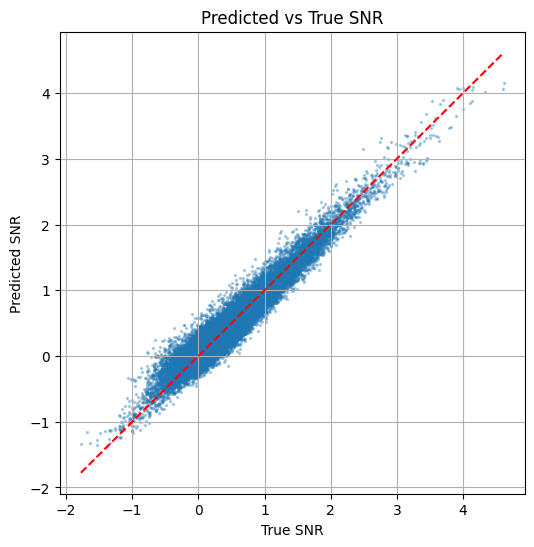

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, s=2, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonale ideale
plt.xlabel("True SNR")
plt.ylabel("Predicted SNR")

plt.title("Predicted vs True SNR")
plt.grid(True)
#plt.axis("equal")
plt.show()

Our regressor accurately predict the SNR values aligning, with a certain spread, along the 45°line.

In [29]:
"""
Tried to do PCA but in order to explain 99.5 % of the variance, the algorithm uses all the initial features and can't really find a linear combination that 
explain the variance better. 


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
file = 'sample_2e7_design_precessing_higherordermodes_3detectors.h5'
name = ['mtot','q','chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'psi','z']

with h5py.File(file, 'r') as data:
  
    gw_tot = [data[n][:10**5] for n in name]
    gw_arr = np.array(gw_tot).T  # (100000, n_features)
   
    y = data['det'][:10**5].astype(int)  

# PCA
X = StandardScaler().fit_transform(gw_arr)
pca = PCA(n_components= 5)  
X_pca = pca.fit_transform(X)

print(f"Explained variance: {pca.explained_variance_ratio_}")


X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)




"""

'\nTried to do PCA but in order to explain 99.5 % of the variance, the algorithm uses all the initial features and can\'t really find a linear combination that \nexplain the variance better. \n\n\nfrom sklearn.decomposition import PCA\nfrom sklearn.preprocessing import StandardScaler\nfile = \'sample_2e7_design_precessing_higherordermodes_3detectors.h5\'\nname = [\'mtot\',\'q\',\'chi1x\', \'chi1y\', \'chi1z\', \'chi2x\', \'chi2y\', \'chi2z\', \'dec\', \'iota\', \'psi\',\'z\']\n\nwith h5py.File(file, \'r\') as data:\n\n    gw_tot = [data[n][:10**5] for n in name]\n    gw_arr = np.array(gw_tot).T  # (100000, n_features)\n\n    y = data[\'det\'][:10**5].astype(int)  \n\n# PCA\nX = StandardScaler().fit_transform(gw_arr)\npca = PCA(n_components= 5)  \nX_pca = pca.fit_transform(X)\n\nprint(f"Explained variance: {pca.explained_variance_ratio_}")\n\n\nX_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=42)\n\n\n\n\n'

In [ ]:
"""
# Random Forest

cv_rnd = KFold(n_splits=5, shuffle=True, random_state=0)
tree_max = {'max_depth': np.arange(1, 26)}
tree_rnd = RandomForestClassifier(random_state = 0, criterion = 'entropy')
grid_rnd = GridSearchCV(tree_rnd, tree_max, cv=cv_rnd, n_jobs=-1, scoring = 'roc_auc')
grid_rnd.fit(X_pca, y)

print(f"Best depth: {grid_rnd.best_params_['max_depth']}")
print(f"Best score: {grid_rnd.best_score_}")
max_depth = grid_rnd.best_params_['max_depth']
"""

'\n# Random Forest\n\ncv_rnd = KFold(n_splits=5, shuffle=True, random_state=0)\ntree_max = {\'max_depth\': np.arange(1, 26)}\ntree_rnd = RandomForestClassifier(random_state = 0, criterion = \'entropy\')\ngrid_rnd = GridSearchCV(tree_rnd, tree_max, cv=cv_rnd, n_jobs=-1, scoring = \'roc_auc\')\ngrid_rnd.fit(X_pca, y)\n\nprint(f"Best depth: {grid_rnd.best_params_[\'max_depth\']}")\nprint(f"Best score: {grid_rnd.best_score_}")\nmax_depth = grid_rnd.best_params_[\'max_depth\']\n'

In [ ]:
"""
clf = RandomForestClassifier(max_depth= max_depth, random_state=0, criterion = 'entropy')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]
"""

"\nclf = RandomForestClassifier(max_depth= max_depth, random_state=0, criterion = 'entropy')\nclf.fit(X_train, y_train)\n\ny_pred = clf.predict(X_test)\ny_prob = clf.predict_proba(X_test)[:, 1]\n"